In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [2]:
df1 = pd.read_csv("Meetinglistdetails_29-05-2026.csv")
df2 = pd.read_csv("Meetinglistdetails_30-05-2026.csv")

print("Day 1 Shape:", df1.shape)
print("Day 2 Shape:", df2.shape)

Day 1 Shape: (5460, 24)
Day 2 Shape: (4399, 24)


In [15]:
attendance = pd.concat([df1, df2], ignore_index=True)
print("Combined Shape:", attendance.shape)
attendance.head()

Combined Shape: (9859, 24)


,Topic,Type,ID,Host name,Host email,Start time,End time,Participants,Duration (minutes),Total participant minutes,Department,Group,Source,Unique viewers,Max concurrent views,Creation time,Name (original name),Email,Join time,Leave time,Duration (minutes).1,Guest,Recording disclaimer response,In waiting room
0,Cloud Computing - DevOps - Summer Online Inter...,Meeting,918 0609 9436,santosh s,venkatasivasantosh.s@apssdc.in,05/29/2026 06:04:58 PM,05/29/2026 08:14:30 PM,972,130,31223,Operations,NaN,Zoom,-,-,05/05/2026 02:35:03 PM,Haritha K,haritha200624@gmail.com,05/29/2026 06:19:49 PM,05/29/2026 06:22:21 PM,3,Yes,OK,No
1,Cloud Computing - DevOps - Summer Online Inter...,Meeting,918 0609 9436,santosh s,venkatasivasantosh.s@apssdc.in,05/29/2026 06:04:58 PM,05/29/2026 08:14:30 PM,972,130,31223,Operations,NaN,Zoom,-,-,05/05/2026 02:35:03 PM,234M1A2559 Uppalapati Pravallika,upravallika75@gmail.com,05/29/2026 06:22:54 PM,05/29/2026 06:24:14 PM,2,Yes,No Response,No
2,Cloud Computing - DevOps - Summer Online Inter...,Meeting,918 0609 9436,santosh s,venkatasivasantosh.s@apssdc.in,05/29/2026 06:04:58 PM,05/29/2026 08:14:30 PM,972,130,31223,Operations,NaN,Zoom,-,-,05/05/2026 02:35:03 PM,keerthika puttan,keerthikaputtan@gmail.com,05/29/2026 06:26:49 PM,05/29/2026 06:29:20 PM,3,Yes,OK,No
3,Cloud Computing - DevOps - Summer Online Inter...,Meeting,918 0609 9436,santosh s,venkatasivasantosh.s@apssdc.in,05/29/2026 06:04:58 PM,05/29/2026 08:14:30 PM,972,130,31223,Operations,NaN,Zoom,-,-,05/05/2026 02:35:03 PM,SANDEEP DOMMETI,dommetisandeep5@gmail.com,05/29/2026 06:26:50 PM,05/29/2026 06:47:32 PM,21,Yes,No Response,No
4,Cloud Computing - DevOps - Summer Online Inter...,Meeting,918 0609 9436,santosh s,venkatasivasantosh.s@apssdc.in,05/29/2026 06:04:58 PM,05/29/2026 08:14:30 PM,972,130,31223,Operations,NaN,Zoom,-,-,05/05/2026 02:35:03 PM,24B81A05P1 Mohammad faiza,mohammadfaizafanar@gmail.com,05/29/2026 06:32:46 PM,05/29/2026 07:57:13 PM,85,Yes,No Response,No


In [16]:
attendance.info()
attendance.describe(include="all")
attendance.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9859 entries, 0 to 9858
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Topic                          9859 non-null   object 
 1   Type                           9859 non-null   object 
 2   ID                             9859 non-null   object 
 3   Host name                      9859 non-null   object 
 4   Host email                     9859 non-null   object 
 5   Start time                     9859 non-null   object 
 6   End time                       9859 non-null   object 
 7   Participants                   9859 non-null   int64  
 8   Duration (minutes)             9859 non-null   int64  
 9   Total participant minutes      9859 non-null   int64  
 10  Department                     9859 non-null   object 
 11  Group                          0 non-null      float64
 12  Source                         9859 non-null   o

Topic                               0
Type                                0
ID                                  0
Host name                           0
Host email                          0
Start time                          0
End time                            0
Participants                        0
Duration (minutes)                  0
Total participant minutes           0
Department                          0
Group                            9859
Source                              0
Unique viewers                      0
Max concurrent views                0
Creation time                       0
Name (original name)                0
Email                               0
Join time                           0
Leave time                          0
Duration (minutes).1                0
Guest                               0
Recording disclaimer response    2237
In waiting room                     0
dtype: int64

In [17]:
duplicate_count = attendance.duplicated().sum()
print("Duplicate Records:", duplicate_count)
attendance = attendance.drop_duplicates()
print("Shape After Removing Duplicates:", attendance.shape)

Duplicate Records: 91
Shape After Removing Duplicates: (9768, 24)


In [18]:
attendance.columns = attendance.columns.str.strip()
attendance['Email'] = attendance['Email'].astype(str)
attendance['Duration (minutes).1'] = pd.to_numeric(
    attendance['Duration (minutes).1'],
    errors='coerce'
)
attendance['Duration (minutes).1'].fillna(0, inplace=True)
attendance.head()

C:\Users\navee\AppData\Local\Temp\ipykernel_8548\3885055930.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  attendance['Duration (minutes).1'].fillna(0, inplace=True)


,Topic,Type,ID,Host name,Host email,Start time,End time,Participants,Duration (minutes),Total participant minutes,Department,Group,Source,Unique viewers,Max concurrent views,Creation time,Name (original name),Email,Join time,Leave time,Duration (minutes).1,Guest,Recording disclaimer response,In waiting room
0,Cloud Computing - DevOps - Summer Online Inter...,Meeting,918 0609 9436,santosh s,venkatasivasantosh.s@apssdc.in,05/29/2026 06:04:58 PM,05/29/2026 08:14:30 PM,972,130,31223,Operations,NaN,Zoom,-,-,05/05/2026 02:35:03 PM,Haritha K,haritha200624@gmail.com,05/29/2026 06:19:49 PM,05/29/2026 06:22:21 PM,3,Yes,OK,No
1,Cloud Computing - DevOps - Summer Online Inter...,Meeting,918 0609 9436,santosh s,venkatasivasantosh.s@apssdc.in,05/29/2026 06:04:58 PM,05/29/2026 08:14:30 PM,972,130,31223,Operations,NaN,Zoom,-,-,05/05/2026 02:35:03 PM,234M1A2559 Uppalapati Pravallika,upravallika75@gmail.com,05/29/2026 06:22:54 PM,05/29/2026 06:24:14 PM,2,Yes,No Response,No
2,Cloud Computing - DevOps - Summer Online Inter...,Meeting,918 0609 9436,santosh s,venkatasivasantosh.s@apssdc.in,05/29/2026 06:04:58 PM,05/29/2026 08:14:30 PM,972,130,31223,Operations,NaN,Zoom,-,-,05/05/2026 02:35:03 PM,keerthika puttan,keerthikaputtan@gmail.com,05/29/2026 06:26:49 PM,05/29/2026 06:29:20 PM,3,Yes,OK,No
3,Cloud Computing - DevOps - Summer Online Inter...,Meeting,918 0609 9436,santosh s,venkatasivasantosh.s@apssdc.in,05/29/2026 06:04:58 PM,05/29/2026 08:14:30 PM,972,130,31223,Operations,NaN,Zoom,-,-,05/05/2026 02:35:03 PM,SANDEEP DOMMETI,dommetisandeep5@gmail.com,05/29/2026 06:26:50 PM,05/29/2026 06:47:32 PM,21,Yes,No Response,No
4,Cloud Computing - DevOps - Summer Online Inter...,Meeting,918 0609 9436,santosh s,venkatasivasantosh.s@apssdc.in,05/29/2026 06:04:58 PM,05/29/2026 08:14:30 PM,972,130,31223,Operations,NaN,Zoom,-,-,05/05/2026 02:35:03 PM,24B81A05P1 Mohammad faiza,mohammadfaizafanar@gmail.com,05/29/2026 06:32:46 PM,05/29/2026 07:57:13 PM,85,Yes,No Response,No


In [7]:
student_attendance = attendance.groupby(
    ['Email', 'Name (original name)']
)['Duration (minutes).1'].sum().reset_index()

student_attendance.rename(
    columns={'Duration (minutes).1': 'Total_Attendance'},
    inplace=True
)

student_attendance.head()

,Email,Name (original name),Total_Attendance
0,2023csm.r119@svce.edu.in,Kannuru SethuMadhav,21
1,2023eee.r145@svce.edu.in,Madibaka Vamsi-23BFA02145 ( Madibaka Vamsi ),80
2,20l31a04i9@gmail.com,teja yeluri 20L31A04I9,86
3,22295cm019@gmail.com,jatla anusha,80
4,23221a0259@bvcgroup.in,23221A0259 Y.Anil Kumar,36


In [8]:
CERTIFICATION_THRESHOLD = 80

student_attendance['Status'] = np.where(
    student_attendance['Total_Attendance'] >= CERTIFICATION_THRESHOLD,
    'Certified',
    'Uncertified'
)

student_attendance.head()

,Email,Name (original name),Total_Attendance,Status
0,2023csm.r119@svce.edu.in,Kannuru SethuMadhav,21,Uncertified
1,2023eee.r145@svce.edu.in,Madibaka Vamsi-23BFA02145 ( Madibaka Vamsi ),80,Certified
2,20l31a04i9@gmail.com,teja yeluri 20L31A04I9,86,Certified
3,22295cm019@gmail.com,jatla anusha,80,Certified
4,23221a0259@bvcgroup.in,23221A0259 Y.Anil Kumar,36,Uncertified


In [9]:
student_attendance['Status'].value_counts()

Status
Uncertified    1726
Certified      1671
Name: count, dtype: int64

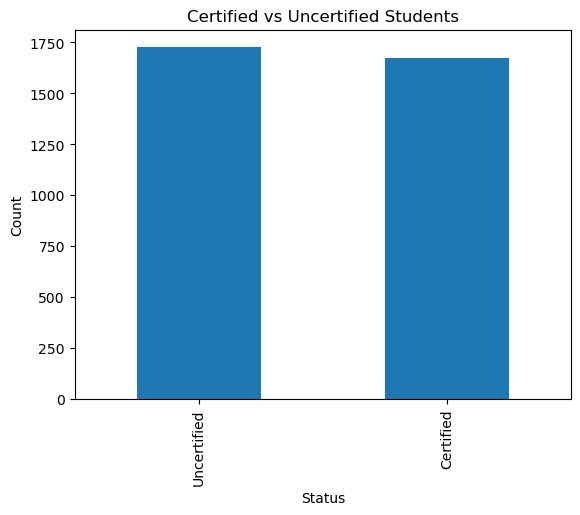

In [10]:
student_attendance['Status'].value_counts().plot(
    kind='bar'
)

plt.title("Certified vs Uncertified Students")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()

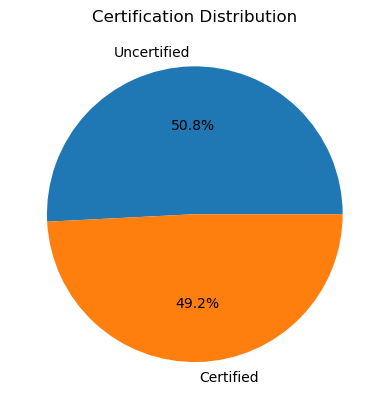

In [11]:
student_attendance['Status'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Certification Distribution")
plt.ylabel("")
plt.show()

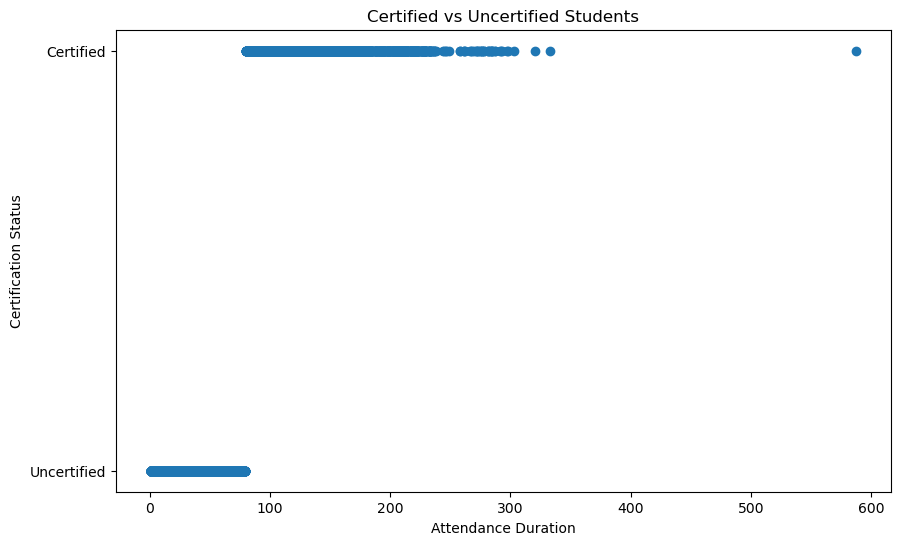

In [12]:
student_attendance['Status_Code'] = student_attendance['Status'].map(
    {
        'Certified': 1,
        'Uncertified': 0
    }
)

plt.figure(figsize=(10,6))

plt.scatter(
    student_attendance['Total_Attendance'],
    student_attendance['Status_Code']
)

plt.yticks([0,1], ['Uncertified','Certified'])

plt.xlabel("Attendance Duration")
plt.ylabel("Certification Status")
plt.title("Certified vs Uncertified Students")

plt.show()

In [13]:
certified_students = student_attendance[
    student_attendance['Status'] == 'Certified'
]

certified_students.head()

,Email,Name (original name),Total_Attendance,Status,Status_Code
1,2023eee.r145@svce.edu.in,Madibaka Vamsi-23BFA02145 ( Madibaka Vamsi ),80,Certified,1
2,20l31a04i9@gmail.com,teja yeluri 20L31A04I9,86,Certified,1
3,22295cm019@gmail.com,jatla anusha,80,Certified,1
10,23221a04j4@bvcgroup.in,MANDELA NAVEEN SAI KRISHNA _ 23221A04J4 ( MAND...,125,Certified,1
13,23221a4203@bvcgroup.in,Akula Jahnavi Lakshmi Pavani,89,Certified,1


In [19]:
student_attendance.to_csv(
    "Final_Certification_Report.csv",
    index=False
)

certified_students.to_csv(
    "Certified_Students.csv",
    index=False
)

print("Files Generated Successfully")

Files Generated Successfully
